<a href="https://colab.research.google.com/github/channel1umut-lang/Deep-Learning/blob/main/0013_Desert101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
import numpy as np

In [ ]:
from pathlib import Path
data_path = Path("data/")
image_path = data_path / "desert101"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Şimdi doğru yol (MyDrive içindeki tam yol):
image_path = "/content/drive/MyDrive/Colab Notebooks/DL Datasets/data/desert101"

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/DL Datasets')
image_path = "data/desert101"   # artık bu geçerli

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
image_path

'data/desert101'

In [ ]:
import os #operation system
def check_data(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path): # os.walk dirpath, dirnames, filenames bize bu degerleri donduruyor.
        print(f"# of directories: {len(dirnames)} and {len(filenames)} images in '{dirpath}'.") # Amacimiz hangi klasorde kac tane gorsel var onu cikartmaya calisiyoruz.

In [ ]:

check_data(image_path)

# of directories: 2 and 1 images in 'data/desert101'.
# of directories: 4 and 1 images in 'data/desert101/train'.
# of directories: 0 and 80 images in 'data/desert101/train/donuts'.
# of directories: 0 and 80 images in 'data/desert101/train/cannoli'.
# of directories: 0 and 80 images in 'data/desert101/train/cup_cakes'.
# of directories: 0 and 80 images in 'data/desert101/train/baklava'.
# of directories: 4 and 1 images in 'data/desert101/test'.
# of directories: 0 and 20 images in 'data/desert101/test/cannoli'.
# of directories: 0 and 20 images in 'data/desert101/test/cup_cakes'.
# of directories: 0 and 20 images in 'data/desert101/test/donuts'.
# of directories: 0 and 20 images in 'data/desert101/test/baklava'.


In [ ]:
Path(image_path).exists()

True

In [ ]:
from pathlib import Path

train_dir = Path(image_path) / "train"
test_dir = Path(image_path) / "test"

In [ ]:
train_dir

PosixPath('data/desert101/train')

In [ ]:
test_dir

PosixPath('data/desert101/test')

In [ ]:
# let's actually see some images
import random
from PIL import Image
from pathlib import Path # Import Path here

random.seed(42)

# 1. Get all image paths
image_path_list = list(Path(image_path).glob("*/*/*.jpg")) # Convert image_path to Path object and fix glob pattern

# 2. Get random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

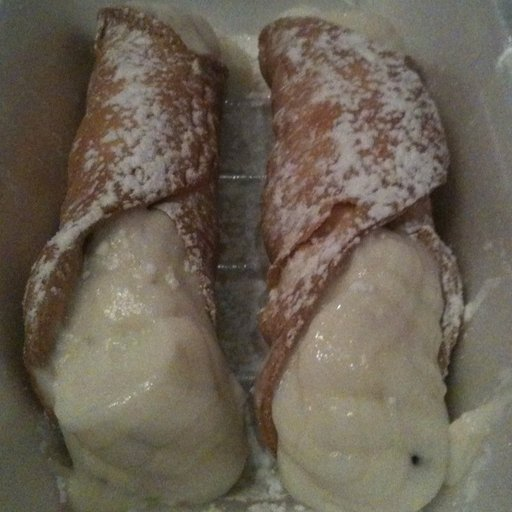

In [ ]:
img

In [ ]:
# let's dive into how we can actually create a custom dataset

In [ ]:
!pip uninstall sympy -y
!pip install sympy==1.12

Found existing installation: sympy 1.12
Uninstalling sympy-1.12:
  Successfully uninstalled sympy-1.12
  Using cached sympy-1.12-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.12-py3-none-any.whl (5.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cpu requires sympy>=1.13.3, but you have sympy 1.12 which is incompatible.


In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
data_transform = transforms.Compose([
    # Resize the images to 64x64 (this will surely make them worse, this is our choice, we can leave it as it is, but most probably we will risk achieving the same result with more computational power)
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.4), # p = probability of flip, 0.4 = 40% chance... %40 İhtimalle: Resim sadece sağa-sola (yatay eksende) aynalanır.
    # Data Augmentation!!
    transforms.TrivialAugmentWide(), # increases data diversity.
    # Turn the image into a torch.Tensor
    transforms.ToTensor()
])

In [ ]:
from torchvision import datasets

train_data = datasets.ImageFolder(root=train_dir,#root = train directory # target folder of images... This step made because  we are using our own dataset.
                                  transform=data_transform, #size i falan ustte ayarladigimiz kodu buraya tanimladik. yani datayi transform etmeye calisiyoruz
                                  target_transform=None) # transforms to perform on labels (if necessary)

test_data = datasets.ImageFolder(root=test_dir, #Boyle ayri ayri hesapliyoruz cunku  data setimiz zaten dosya halinde test we train diye ikiye ayrilmisti %80 e %20 olacak sekilde
                                 transform=data_transform)

In [ ]:
train_data

Dataset ImageFolder
    Number of datapoints: 316
    Root location: data/desert101/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [ ]:
test_data

Dataset ImageFolder
    Number of datapoints: 77
    Root location: data/desert101/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [ ]:
# we will also need labels (class names)

In [ ]:
class_names = train_data.classes

In [ ]:
class_names # classlarimizi duzgunce ayirmistik buraya yuklemeden once. o yuzden duzgunce alabiliyoruz.

['baklava', 'cannoli', 'cup_cakes', 'donuts']

In [ ]:
len(train_data), len(test_data)

(316, 77)

In [ ]:
# now we can pass this data image to dataloader so we can finally get our data ready for nn

In [ ]:
#DataLoader olmadan verileri manuel olarak batch’lere bölmek, her epoch’ta karıştırmak ve çok iş parçacığıyla yüklemek zorunda kalırdık. DataLoader bu işlemleri tek satırda, optimize edilmiş ve hatasız bir şekilde yapar.
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count() # in order to use our cpus.
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE, # how many samples per batch?
                              num_workers=NUM_WORKERS, # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=NUM_WORKERS,
                             shuffle=False)

In [ ]:
# we finally have the data ready, let's move onto creating nn and see if it works out

In [ ]:
test_dataloader.dataset[0][0][0].shape, test_dataloader.dataset[0][0].shape

(torch.Size([64, 64]), torch.Size([3, 64, 64]))

In [ ]:
train_dataloader

In [ ]:
class DesertClassifier(nn.Module): #DesertClassifier = child class, nn.Module = parent class , super().__init__() = bu kismi "__init__()" hem parent hemde child class icin calistir demek.
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__() # nn.Module = içindeki başlangıç işlemlerini çalıştırır.
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*16*16,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [ ]:
torch.manual_seed(42)
model_0 = DesertClassifier(input_shape=3, # number of color channels (3 for RGB)
                  hidden_units=32, #Number of feature map. in the conv layer
                  output_shape=len(train_data.classes))

In [ ]:
!pip install torchinfo
# this is also how you can calculate what to write in output shape in classifier layer
from torchinfo import summary
summary(model_0, input_size=[1, 3, 64, 64]) # do a test pass through of an example input size

Layer (type:depth-idx)                   Output Shape              Param #
DesertClassifier                         [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

In [ ]:
#8192 giriş al 4 çıktı üret. Flatten: [1, 8192] Linear:  [1, 4]

In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):

        # 1. Forward pass
        y_pred = model(X) # Random tahminler uretir.

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step() # agirliklari guncelliyoruz burda

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred) #% de olarak gosterdi

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [ ]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [ ]:
# finally create a train function that combines both of them
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        #Bu kod, train_loss değerini results["train_loss"] listesine ekler. Eğer train_loss bir PyTorch tensörü ise (örn. GPU üzerinde bir sayı), .item() ile içindeki Python sayısını (scalar) alır; değilse olduğu gibi kullanır.
        #Böylece listede her zaman sayısal (tensor olmayan) bir değer saklanır.
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [ ]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 10

# Recreate an instance of model
model_0 = DesertClassifier(input_shape=3,
                  hidden_units=32,
                  output_shape=len(train_data.classes))

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)


Epoch: 1 | train_loss: 1.3944 | train_acc: 0.2330 | test_loss: 1.3828 | test_acc: 0.2188
Epoch: 2 | train_loss: 1.3846 | train_acc: 0.2437 | test_loss: 1.3813 | test_acc: 0.2292
Epoch: 3 | train_loss: 1.3750 | train_acc: 0.2799 | test_loss: 1.3745 | test_acc: 0.2083
Epoch: 4 | train_loss: 1.3527 | train_acc: 0.3286 | test_loss: 1.3435 | test_acc: 0.3333
Epoch: 5 | train_loss: 1.3283 | train_acc: 0.3375 | test_loss: 1.3409 | test_acc: 0.2909
Epoch: 6 | train_loss: 1.3142 | train_acc: 0.3902 | test_loss: 1.3497 | test_acc: 0.3117
Epoch: 7 | train_loss: 1.2572 | train_acc: 0.4237 | test_loss: 1.2245 | test_acc: 0.4559
Epoch: 8 | train_loss: 1.2404 | train_acc: 0.4241 | test_loss: 1.3384 | test_acc: 0.3221
Epoch: 9 | train_loss: 1.2567 | train_acc: 0.4129 | test_loss: 1.2322 | test_acc: 0.4712
Epoch: 10 | train_loss: 1.2157 | train_acc: 0.4304 | test_loss: 1.2611 | test_acc: 0.4207


In [ ]:
model_0_results

{'train_loss': [1.394391131401062,
  1.384561550617218,
  1.375035572052002,
  1.3526501297950744,
  1.3283209562301637,
  1.314237892627716,
  1.257218098640442,
  1.2403785049915315,
  1.2567378044128419,
  1.2156864285469056],
 'train_acc': [0.2330357142857143,
  0.24375,
  0.2799107142857143,
  0.32857142857142857,
  0.3375,
  0.39017857142857143,
  0.42366071428571433,
  0.4241071428571429,
  0.41294642857142855,
  0.4303571428571429],
 'test_loss': [1.3828106721242268,
  1.3812652031580608,
  1.3744839827219646,
  1.3435374895731609,
  1.3409266074498494,
  1.3497016032536824,
  1.2245179414749146,
  1.3384213050206502,
  1.2322051525115967,
  1.2611225446065266],
 'test_acc': [0.21875,
  0.22916666666666666,
  0.20833333333333334,
  0.3333333333333333,
  0.29086538461538464,
  0.31169871794871795,
  0.4559294871794872,
  0.32211538461538464,
  0.4711538461538461,
  0.4206730769230769]}

In [ ]:
import matplotlib.pyplot as plt
def plot_loss_curves(results):
    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

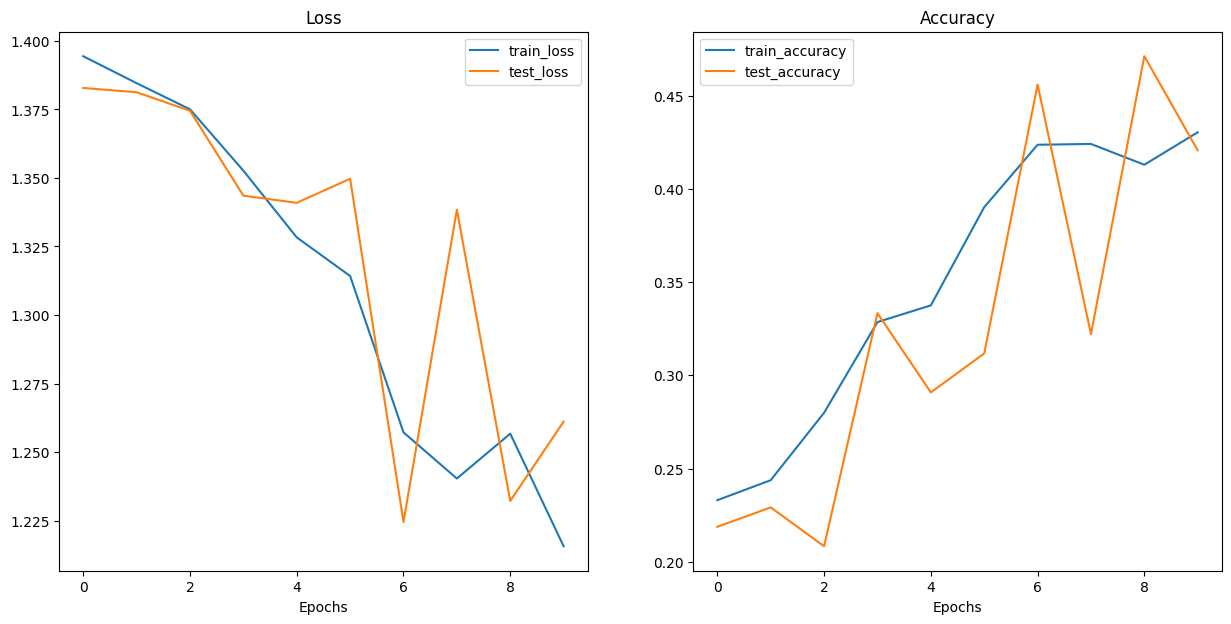

In [ ]:
plot_loss_curves(model_0_results)

In [ ]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0) #  [C, H, W] boyutunu [1, C, H, W] yap (batch boyutu ekle).

            # Logits al. Forward prop
            pred_logit = model(sample)
            """ pred_logit = model(sample) = conv_block_1(x) → Conv2d + ReLU + Conv2d + ReLU + MaxPool2d  → conv_block_2(...) → Conv2d + ReLU + Conv2d + ReLU + MaxPool2d

            classifier(...) → Flatten + Linear   # shape: [1, num_classes]
            """
            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Hepsini birleştir → [N, num_classes]
    return torch.stack(pred_probs)

In [ ]:
#Verilen veri setinden rastgele n tane resim seçer (varsayılan 9), modelin tahminini yapar, görüntüleri ve tahminleri (doğru/yanlış renkli) bir tablo halinde gösterir.
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()

    plt.figure(figsize=(4, 4))

    # random 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # modele uygun hale getir
            img_input = img.unsqueeze(0)
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # görseli çizmek için permute
            img_show = img.permute(1, 2, 0)

            # doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # subplot
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

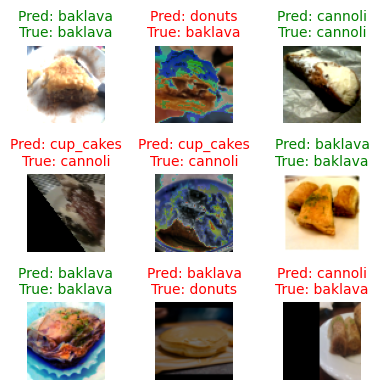

In [ ]:
show_random_predictions(model_0, test_data, class_names)

In [ ]:
# let's find a baklava image online and try with that

In [ ]:
online_image_path = data_path / "baklava_online.jpg"

In [ ]:
online_image_path

PosixPath('data/baklava_online.jpg')

In [ ]:
import torchvision
single_image = torchvision.io.read_image(str(online_image_path))

In [ ]:
single_image

tensor([[[88, 88, 89,  ..., 40, 40, 40],
         [88, 89, 89,  ..., 40, 40, 40],
         [89, 89, 89,  ..., 40, 40, 40],
         ...,
         [25, 25, 25,  ..., 60, 62, 64],
         [24, 24, 25,  ..., 60, 62, 63],
         [23, 23, 26,  ..., 58, 59, 60]],

        [[82, 82, 84,  ..., 40, 40, 40],
         [82, 83, 84,  ..., 40, 40, 40],
         [83, 83, 84,  ..., 40, 40, 40],
         ...,
         [27, 27, 27,  ..., 60, 62, 64],
         [26, 26, 27,  ..., 60, 62, 63],
         [28, 28, 28,  ..., 59, 60, 61]],

        [[30, 30, 29,  ..., 42, 42, 42],
         [30, 31, 29,  ..., 40, 40, 40],
         [31, 31, 29,  ..., 40, 40, 40],
         ...,
         [26, 26, 24,  ..., 52, 54, 56],
         [25, 25, 24,  ..., 52, 54, 55],
         [24, 24, 25,  ..., 53, 54, 53]]], dtype=torch.uint8)

single image is in tensor format, however, this is uint8 dtype

It means that its values are between [0, 255]. But our model takes image tensors of datatype torch.float32 and with values between [0, 1].

So we need to tranform it a little bit

In [ ]:
# we should spesify the float32 dtype here like this
single_image = torchvision.io.read_image(str(online_image_path)).type(torch.float32)

In [ ]:
# then convert numbers into [0,1] by dividing it to 255
single_image = single_image / 255

(np.float64(-0.5), np.float64(2999.5), np.float64(1856.5), np.float64(-0.5))

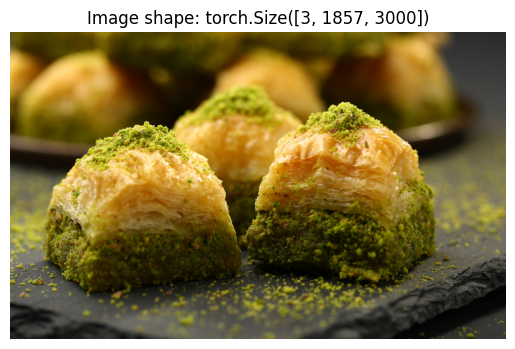

In [ ]:
plt.imshow(single_image.permute(1, 2, 0))
plt.title(f"Image shape: {single_image.shape}")
plt.axis(False)

In [ ]:
# we should do the resize transform as well
single_image_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
])

# Transform target image
single_image = single_image_transform(single_image)

In [ ]:
single_image.shape

torch.Size([3, 64, 64])

In [ ]:
single_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 64, 64])

In [ ]:
single_image = single_image.unsqueeze(dim=0)

In [ ]:
model_0.eval()
with torch.inference_mode():

    logits = model_0(single_image)
    probs = torch.softmax(logits, dim=1)
    pred_idx = probs.argmax(dim=1).item()

print("Predicted class:", class_names[pred_idx])

Predicted class: baklava
